# Exploratory Data Analysis (EDA)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Load dataset
dataset_path = Path('../data/dataset.csv')
df = pd.read_csv(dataset_path)

print(f"Dataset shape: {df.shape}")
print(f"Total rows: {df.shape[0]:,}, Total columns: {df.shape[1]}")

Dataset shape: (86691, 85)
Total rows: 86,691, Total columns: 85


## 1. Basic Information

In [4]:
# Data infomation
df.info()

# First 5 rows
print("\nFIRST 5 ROWS")
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86691 entries, 0 to 86690
Data columns (total 85 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Flow ID                     86691 non-null  object 
 1   Src IP                      86691 non-null  object 
 2   Src Port                    86691 non-null  int64  
 3   Dst IP                      86691 non-null  object 
 4   Dst Port                    86691 non-null  int64  
 5   Protocol                    86691 non-null  int64  
 6   Timestamp                   86691 non-null  object 
 7   Flow Duration               86691 non-null  int64  
 8   Total Fwd Packet            86691 non-null  int64  
 9   Total Bwd packets           86691 non-null  int64  
 10  Total Length of Fwd Packet  86691 non-null  float64
 11  Total Length of Bwd Packet  86691 non-null  float64
 12  Fwd Packet Length Max       86691 non-null  float64
 13  Fwd Packet Length Min       866

,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Total Fwd Packet,Total Bwd packets,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Activity,Stage
0,8.0.6.4-8.6.0.1-0-0-0,8.6.0.1,0,8.0.6.4,0,0,15/07/2019 01:55:21 PM,119998944,242,1,...,0.000000,0.000000,0.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,Normal,Benign
1,192.168.3.10-239.2.11.71-53569-8662-17,192.168.3.10,53569,239.2.11.71,8662,17,15/07/2019 01:55:22 PM,109235816,21,1,...,819535.500000,78517.844090,875056.0,764015.0,1.517532e+07,6.349189e+06,20019201.0,5202524.0,Normal,Benign
2,255.255.255.255-0.0.0.0-67-68-17,0.0.0.0,68,255.255.255.255,67,17,15/07/2019 01:55:22 PM,119764062,88,1,...,0.000000,0.000000,0.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,Normal,Benign
3,192.168.3.30-192.168.3.31-40504-9200-6,192.168.3.30,40504,192.168.3.31,9200,6,15/07/2019 01:55:23 PM,117030424,18,17,...,192329.333333,436593.123269,1083374.0,7236.0,1.931131e+07,1.177830e+07,34978598.0,5147962.0,Normal,Benign
4,0.87.248.248-3.0.0.0-0-0-0,0.87.248.248,0,3.0.0.0,0,0,15/07/2019 01:55:58 PM,119999703,2,1,...,0.000000,0.000000,0.0,0.0,5.999985e+07,8.478210e+02,60000451.0,59999252.0,Normal,Benign


## 2. Missing Values & Data Quality Analysis

In [27]:
# Check missing values
missing = df.isnull().sum()
print(f"MISSING VALUES: {missing.sum()}")

# Check for duplicates
duplicate = df.duplicated()
print(f"\nDUPLICATE ROWS: {duplicate.sum()}")

MISSING VALUES: 0

DUPLICATE ROWS: 0


## 3. Target Variable Distribution

TARGET VARIABLE: 'Activity':
                        Count  Percentage
Activity                                 
Normal                  44258   51.052589
BENIGN                  19454   22.440622
Directory Bruteforce     9970   11.500617
Network Scan             7742    8.930569
Web Vulnerability Scan   2574    2.969166
Account Discovery        2408    2.777682
Account Bruteforce        141    0.162647
SQL Injection              84    0.096896
Backdoor                   20    0.023070
Privilege Escalation       13    0.014996
Command Injection          12    0.013842
CSRF                        7    0.008075
Data Exfiltration           6    0.006921
Malware Download            2    0.002307


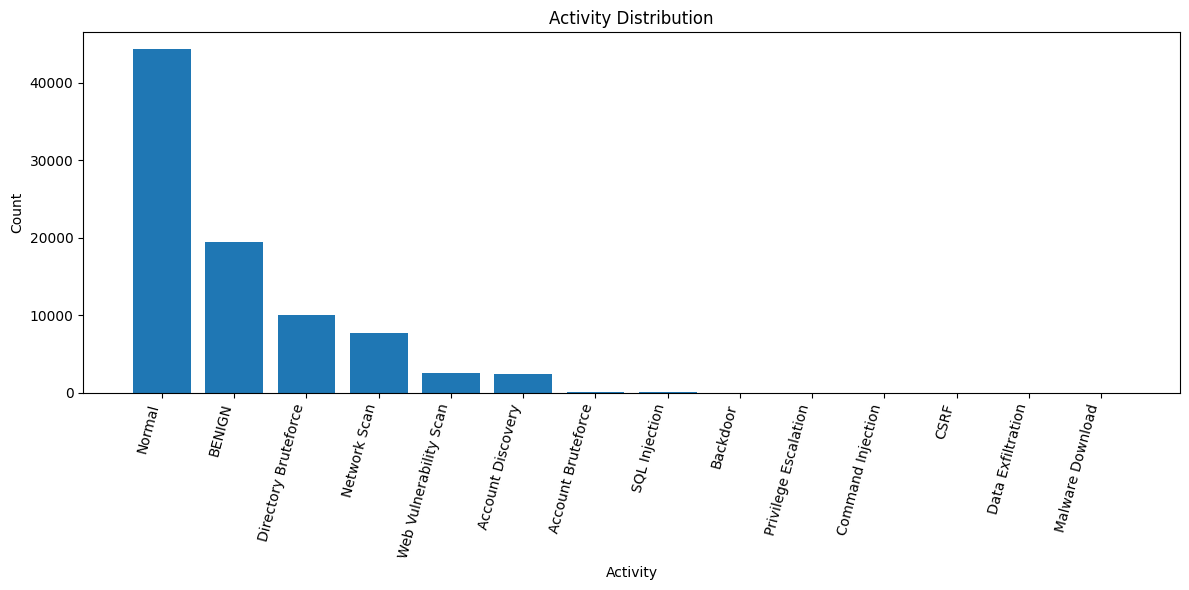


TARGET VARIABLE: 'Stage':
                    Count  Percentage
Stage                                
Benign              44258   51.052589
BENIGN              19454   22.440622
Reconnaissance      11909   13.737297
Establish Foothold   8604    9.924906
Lateral Movement     2451    2.827283
Data Exfiltration      15    0.017303


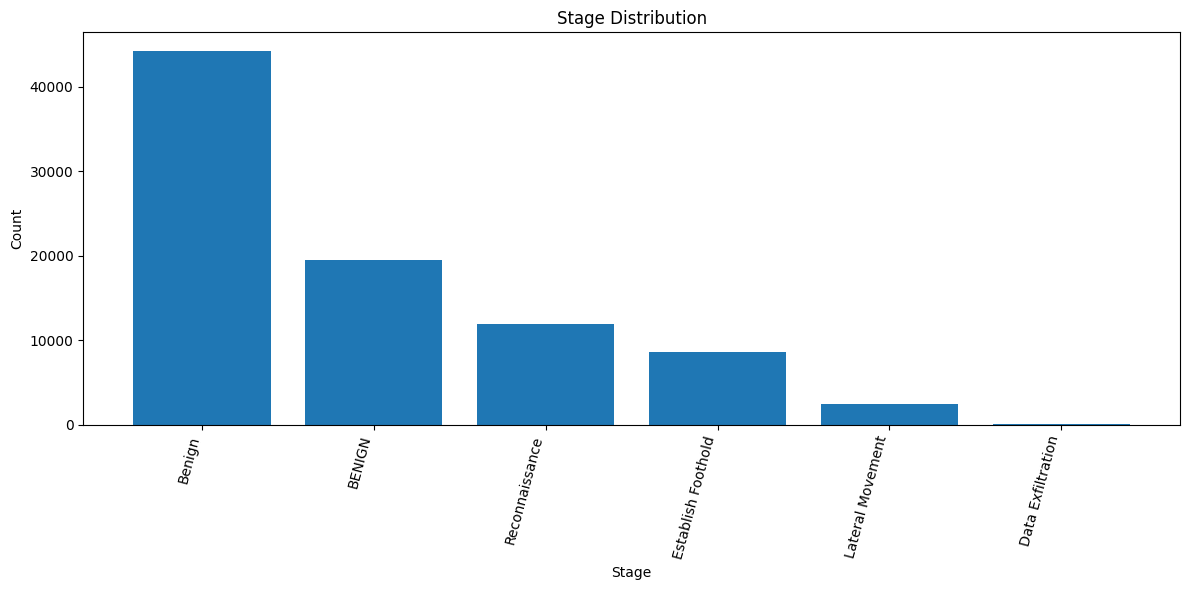

In [9]:
# Target variable
target_col_1 = 'Activity'
print(f"TARGET VARIABLE: '{target_col_1}':")
    
# Value counts, percentage
counts_1 = df[target_col_1].value_counts()
counts_per_1 = df[target_col_1].value_counts(normalize=True) * 100

result_1 = pd.DataFrame({
    "Count": counts_1,
    "Percentage": counts_per_1.round(6)
})
print(result_1)

# Visualization
plt.figure(figsize=(12, 6))
plt.bar(counts_1.index, counts_1.values)
plt.xticks(rotation=75, ha='right')
plt.xlabel("Activity")
plt.ylabel("Count")
plt.title("Activity Distribution")
plt.tight_layout()
plt.show()


# Target variable     
target_col_2 = 'Stage'
print(f"\nTARGET VARIABLE: '{target_col_2}':")

# Value counts
counts_2 = df[target_col_2].value_counts()
counts_per_2 = df[target_col_2].value_counts(normalize=True) * 100

result_2 = pd.DataFrame({
    "Count": counts_2,
    "Percentage": counts_per_2.round(6)
})
print(result_2)

# Visualization
plt.figure(figsize=(12, 6))
plt.bar(counts_2.index, counts_2.values)
plt.xticks(rotation=75, ha='right')
plt.xlabel("Stage")
plt.ylabel("Count")
plt.title("Stage Distribution")
plt.tight_layout()
plt.show()


In [10]:
# Create merged dataframe, combine both Benign categories
df_merged = df.copy()
# Merge 'Normal' and 'BENIGN' into one 'Benign' category
# All other activities are considered 'Attack'
df_merged['Activity_Merged'] = df_merged['Activity'].apply(
    lambda x: 'Normal' if x in ['Normal', 'BENIGN'] else 'Attack'
)

print("Merged Activity distribution:")
print(df_merged['Activity_Merged'].value_counts())
print("\nPercentage distribution:")
print(df_merged['Activity_Merged'].value_counts(normalize=True) * 100)
df_merged = df_merged.drop(columns=['Stage', 'Activity'])

Merged Activity distribution:
Activity_Merged
Normal    63712
Attack    22979
Name: count, dtype: int64

Percentage distribution:
Activity_Merged
Normal    73.493212
Attack    26.506788
Name: proportion, dtype: float64
